## ⚠️ Exploratorio — etapa 0, nada congelado

Inventario de PlantVillage y PlantDoc: conteos, integridad, verificación formal de la
exclusión de maíz, borrador de mapeo de clases, insumos para la decisión de partición de
PlantDoc y detección de casi-duplicados. **No se entrena ningún modelo, no se calcula
ninguna métrica de desempeño, no se escribe nada en `data/splits/`.**

Contexto completo: `handoff.md`, `CLAUDE.md`, `docs/propuesta_entregable1.md`. Decisiones
ya tomadas por el equipo (no se vuelven a discutir acá): CAM sin Grad-CAM, exclusión de
maíz del subconjunto común, base tomate+papa evaluando sumar pimiento. La partición
dev/test de PlantDoc **no** se decide en esta sesión — el objetivo es juntar evidencia
numérica para la reunión con el docente.

Código reutilizable en `src/foliares/data/`; este notebook solo orquesta y muestra
resultados. Config: `configs/00_exploracion_datasets.yaml`.

In [1]:
import sys, json, random, subprocess, csv
from pathlib import Path
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from foliares.data import inventario, leaf_grouping, duplicados, taxonomia

with open(ROOT / "configs" / "00_exploracion_datasets.yaml", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

RNG = random.Random(CFG["semilla"])

PV_COLOR = ROOT / CFG["rutas"]["plantvillage_color"]
PV_SEG = ROOT / CFG["rutas"]["plantvillage_segmented"]
PV_LEAFMAP = ROOT / CFG["rutas"]["plantvillage_leaf_map"]
PD_TRAIN = ROOT / CFG["rutas"]["plantdoc_train"]
PD_TEST = ROOT / CFG["rutas"]["plantdoc_test"]

print("Semilla:", CFG["semilla"])
print("Commits fijados:", CFG["commits_fijados"])

Semilla: 20260925
Commits fijados: {'plantvillage': '7f7ecc7e1eaca78107e3affe7cb5abd9427e139a', 'plantdoc': '5467f6012d78d1c446145d5f582da6096f852ae8'}


## 0. Verificación de commits

Se verifica que el `HEAD` de cada clon local coincide exactamente con el commit fijado en
`docs/bitacora/decisiones.md`.

In [2]:
def head_de(repo):
    return subprocess.run(["git", "-C", str(repo), "rev-parse", "HEAD"],
                           capture_output=True, text=True, check=True).stdout.strip()

head_pv = head_de(ROOT / "data/raw/plantvillage")
head_pd = head_de(ROOT / "data/raw/plantdoc")

assert head_pv == CFG["commits_fijados"]["plantvillage"], f"PlantVillage HEAD no coincide: {head_pv}"
assert head_pd == CFG["commits_fijados"]["plantdoc"], f"PlantDoc HEAD no coincide: {head_pd}"
print("PlantVillage HEAD:", head_pv, "OK")
print("PlantDoc HEAD:", head_pd, "OK")

PlantVillage HEAD: 7f7ecc7e1eaca78107e3affe7cb5abd9427e139a OK
PlantDoc HEAD: 5467f6012d78d1c446145d5f582da6096f852ae8 OK


## 1. Inventario PlantVillage (color vs. segmented)

Conteo por clase en ambas variantes; deben coincidir. Chequeo de integridad: archivos
ilegibles, resoluciones atípicas, imágenes en escala de grises dentro de `color/`.

In [3]:
conteos_color = inventario.contar_por_clase(PV_COLOR)
conteos_seg = inventario.contar_por_clase(PV_SEG)

print(f"Clases: {len(conteos_color)} (color), {len(conteos_seg)} (segmented)")
print(f"Total color: {sum(conteos_color.values())}")
print(f"Total segmented: {sum(conteos_seg.values())}")

diffs = {k: (conteos_color.get(k, 0), conteos_seg.get(k, 0))
         for k in set(conteos_color) | set(conteos_seg)
         if conteos_color.get(k, 0) != conteos_seg.get(k, 0)}
print(f"Clases con diferencia color vs. segmented ({len(diffs)}):")
for clase, (c, s) in diffs.items():
    print(f"  {clase}: color={c}  segmented={s}  diferencia={s-c:+d}")

Clases: 38 (color), 38 (segmented)
Total color: 54305
Total segmented: 54306
Clases con diferencia color vs. segmented (1):
  Grape___Esca_(Black_Measles): color=1383  segmented=1384  diferencia=+1


In [4]:
resumen_color = inventario.verificar_integridad(PV_COLOR, chequear_escala_de_grises=True)
resumen_seg = inventario.verificar_integridad(PV_SEG, chequear_escala_de_grises=False)

print("color:", resumen_color.n_archivos, "archivos; hallazgos:", resumen_color.contar_por_tipo())
print("segmented:", resumen_seg.n_archivos, "archivos; hallazgos:", resumen_seg.contar_por_tipo())

print("Resoluciones distintas en color:", len(resumen_color.resoluciones), "->", resumen_color.resoluciones)
print("Resoluciones distintas en segmented:", len(resumen_seg.resoluciones))
atipicas_seg = {r: n for r, n in resumen_seg.resoluciones.items() if r != (256, 256)}
print("Resoluciones atípicas en segmented (!= 256x256):", atipicas_seg)

color: 54305 archivos; hallazgos: {}
segmented: 54306 archivos; hallazgos: {}
Resoluciones distintas en color: 1 -> {(256, 256): 54305}
Resoluciones distintas en segmented: 5
Resoluciones atípicas en segmented (!= 256x256): {(466, 512): 1, (324, 512): 1, (470, 512): 1, (335, 512): 1}


## 2. Inventario PlantDoc (train / test oficiales)

**Nota de filesystem (no metodológica):** 101 de los 2581 archivos del árbol oficial no se
pudieron materializar con su nombre original en NTFS (87 con `?` en el nombre, 8 con ruta
demasiado larga, 6 perdidos por colisión de mayúsculas/minúsculas). Se rescataron por hash
de blob (`git cat-file`) y se guardaron con nombre saneado — el árbol oficial no se tocó y
no se perdió ninguna imagen. Mapeo completo en
`docs/bitacora/plantdoc_archivos_renombrados.csv`. Los conteos de esta sección salen del
árbol de git (autoritativos), no del disco, así que no están afectados por este problema.

In [5]:
def arbol_git(repo, rev):
    salida = subprocess.run(["git", "-C", str(repo), "ls-tree", "-r", "--name-only", rev],
                             capture_output=True, text=True, check=True).stdout
    return [l for l in salida.splitlines() if l]

rutas_pd = arbol_git(ROOT / "data/raw/plantdoc", CFG["commits_fijados"]["plantdoc"])

import collections
conteo_arbol = collections.Counter()
for p in rutas_pd:
    partes = p.split("/")
    if len(partes) == 3 and partes[0] in ("train", "test"):
        conteo_arbol[(partes[0], partes[1])] += 1

clases_pd = sorted({c for (_s, c) in conteo_arbol})
print(f"{len(clases_pd)} clases oficiales (train ∪ test)")
print(f'{"clase":45s} {"train":>6s} {"test":>6s}')
for c in clases_pd:
    print(f'{c:45s} {conteo_arbol[("train", c)]:>6d} {conteo_arbol[("test", c)]:>6d}')

total_train = sum(v for (s, _c), v in conteo_arbol.items() if s == "train")
total_test = sum(v for (s, _c), v in conteo_arbol.items() if s == "test")
print(f"TOTAL  train={total_train}  test={total_test}  (train+test={total_train+total_test})")
print("Propuesta cita 2.598 imágenes para PlantDoc; el árbol oficial de este commit da",
      total_train + total_test, "en train+test. Diferencia sin resolver, queda documentada.")

28 clases oficiales (train ∪ test)
clase                                          train   test
Apple Scab Leaf                                   83     10
Apple leaf                                        82      9
Apple rust leaf                                   79     10
Bell_pepper leaf                                  53      8
Bell_pepper leaf spot                             62      9
Blueberry leaf                                   106     11
Cherry leaf                                       47     10
Corn Gray leaf spot                               64      4
Corn leaf blight                                 180     12
Corn rust leaf                                   106     10
Peach leaf                                       103      9
Potato leaf early blight                         109      8
Potato leaf late blight                           97      8
Raspberry leaf                                   112      7
Soyabean leaf                                     57      8
Squas

In [6]:
clase_dup = "Tomato two spotted spider mites leaf"
print(f'"{clase_dup}": train={conteo_arbol[("train", clase_dup)]} test={conteo_arbol[("test", clase_dup)]}')
assert conteo_arbol[("train", clase_dup)] == 2 and conteo_arbol[("test", clase_dup)] == 0
print("Confirmado: 2 en train, 0 en test -> sin imágenes para evaluar OOD en esta clase.")

"Tomato two spotted spider mites leaf": train=2 test=0
Confirmado: 2 en train, 0 en test -> sin imágenes para evaluar OOD en esta clase.


In [7]:
conteos_train_disco = inventario.contar_por_clase_split(PD_TRAIN)
conteos_test_disco = inventario.contar_por_clase_split(PD_TEST)
print("En disco (post-rescate) -> train:", sum(conteos_train_disco.values()),
      " test:", sum(conteos_test_disco.values()))
print("Coincide con el árbol oficial:",
      sum(conteos_train_disco.values()) == total_train and sum(conteos_test_disco.values()) == total_test)

resumen_train = inventario.verificar_integridad(PD_TRAIN)
resumen_test = inventario.verificar_integridad(PD_TEST)
print("train: hallazgos:", resumen_train.contar_por_tipo())
print("test: hallazgos:", resumen_test.contar_por_tipo())
print("Resoluciones distintas en train:", len(resumen_train.resoluciones),
      "(vs. una sola resolución fija en PlantVillage — refleja condiciones de campo heterogéneas)")
print("Top 10 resoluciones más frecuentes en train:",
      sorted(resumen_train.resoluciones.items(), key=lambda x: -x[1])[:10])

En disco (post-rescate) -> train: 2342  test: 236
Coincide con el árbol oficial: True


train: hallazgos: {}
test: hallazgos: {}
Resoluciones distintas en train: 1382 (vs. una sola resolución fija en PlantVillage — refleja condiciones de campo heterogéneas)
Top 10 resoluciones más frecuentes en train: [((1600, 1200), 59), ((800, 600), 54), ((1024, 768), 50), ((640, 480), 28), ((1200, 1600), 25), ((3264, 2448), 21), ((1200, 900), 19), ((400, 300), 17), ((900, 675), 17), ((500, 375), 16)]


## 3. Verificación formal de la exclusión de maíz (leaf_grouping)

Se reproduce la lógica exacta de `_generate_examples` en el loader oficial
(`data/raw/plantvillage/plant_village.py`) para calcular el `leaf_id` de cada imagen de
color a partir de `leaf_grouping/leaf-map.json`, y se mide qué porcentaje de imágenes de
cada cultivo candidato obtiene un `leaf_id` real (mapeado) vs. `fallback_...` (no
encontrado en el mapa oficial). Esto es evidencia para la bitácora — la exclusión de maíz
ya fue decidida por el equipo, esto solo la documenta formalmente.

In [8]:
leaf_map = leaf_grouping.cargar_leaf_map(PV_LEAFMAP)
clases_por_cultivo = {c: taxonomia.clases_plantvillage_de_cultivo(c) for c in taxonomia.CULTIVOS_CANDIDATOS}

cobertura = leaf_grouping.cobertura_por_cultivo(PV_COLOR, leaf_map, clases_por_cultivo)

print(f'{"cultivo":10s} {"n":>6s} {"mapeadas":>9s} {"fallback":>9s} {"cobertura":>10s}')
for cultivo, d in cobertura.items():
    print(f'{cultivo:10s} {d["n"]:>6d} {d["mapeadas"]:>9d} {d["fallback"]:>9d} {d["cobertura_pct"]:>9.2f}%')

cultivo         n  mapeadas  fallback  cobertura
maiz         3852         0      3852      0.00%
tomate      18160     11411      6749     62.84%
papa         2152      2152         0    100.00%
pimiento     2475      2473         2     99.92%


## 4. Mapeo candidato de clases (tomate, papa, pimiento)

Borrador completo con las ambigüedades marcadas en `docs/mapeo_clases.md` (no se cierra
acá). Resumen rápido de conteos:

In [9]:
for cultivo, clases_pv in [(c, taxonomia.clases_plantvillage_de_cultivo(c)) for c in ("tomate", "papa", "pimiento")]:
    print(f"--- {cultivo} ---")
    for c in clases_pv:
        print(f"  PlantVillage {c:45s} n={conteos_color.get(c,0)}")
    for c in taxonomia.CLASES_PLANTDOC_CANDIDATAS[cultivo]:
        print(f"  PlantDoc     {c:45s} train={conteo_arbol[('train',c)]} test={conteo_arbol[('test',c)]}")
    print()

--- tomate ---
  PlantVillage Tomato___Bacterial_spot                       n=2127
  PlantVillage Tomato___Early_blight                         n=1000
  PlantVillage Tomato___Late_blight                          n=1909
  PlantVillage Tomato___Leaf_Mold                            n=952
  PlantVillage Tomato___Septoria_leaf_spot                   n=1771
  PlantVillage Tomato___Spider_mites Two-spotted_spider_mite n=1676
  PlantVillage Tomato___Target_Spot                          n=1404
  PlantVillage Tomato___Tomato_Yellow_Leaf_Curl_Virus        n=5357
  PlantVillage Tomato___Tomato_mosaic_virus                  n=373
  PlantVillage Tomato___healthy                              n=1591
  PlantDoc     Tomato Early blight leaf                      train=79 test=9
  PlantDoc     Tomato Septoria leaf spot                     train=140 test=11
  PlantDoc     Tomato leaf                                   train=55 test=8
  PlantDoc     Tomato leaf bacterial spot                    train=101 tes

## 5. Insumos para la decisión de partición de PlantDoc

### 5a. Conteos reales train/test oficiales (ya existen, esto no parte nada)

Ya mostrados en la sección 2 (tabla completa) y el resumen de la sección 4 por clase
candidata.

### 5b. ⚠️ NO CONGELADO — simulación ilustrativa de partición propia (75/25)

Solo para comparar en la reunión con el docente. Se calcula sobre el **pool** (train+test)
de las clases candidatas de tomate, papa y pimiento. **No se guarda en `data/splits/`, no
es definitiva, no se usa para evaluar nada.**

In [10]:
clases_candidatas = sum(taxonomia.CLASES_PLANTDOC_CANDIDATAS.values(), [])
prop_train = CFG["particion_ilustrativa_no_congelada"]["proporcion_train"]

print("### SIMULACIÓN ILUSTRATIVA — NO CONGELADA — NO USAR PARA EVALUAR ###")
print(f'{"clase":40s} {"train_of":>9s} {"test_of":>8s} {"pool":>5s} {int(prop_train*100)}pct {100-int(prop_train*100)}pct')
tot_pool = tot_a = tot_b = 0
for c in clases_candidatas:
    tr, te = conteo_arbol[("train", c)], conteo_arbol[("test", c)]
    pool = tr + te
    n_a = round(pool * prop_train)
    n_b = pool - n_a
    tot_pool += pool; tot_a += n_a; tot_b += n_b
    print(f'{c:40s} {tr:>9d} {te:>8d} {pool:>5d} {n_a:>6d} {n_b:>6d}')
print(f'{"TOTAL":40s} {"":>9s} {"":>8s} {tot_pool:>5d} {tot_a:>6d} {tot_b:>6d}')

### SIMULACIÓN ILUSTRATIVA — NO CONGELADA — NO USAR PARA EVALUAR ###
clase                                     train_of  test_of  pool 75pct 25pct
Tomato Early blight leaf                        79        9    88     66     22
Tomato Septoria leaf spot                      140       11   151    113     38
Tomato leaf                                     55        8    63     47     16
Tomato leaf bacterial spot                     101        9   110     82     28
Tomato leaf late blight                        101       10   111     83     28
Tomato leaf mosaic virus                        44       10    54     40     14
Tomato leaf yellow virus                        70        6    76     57     19
Tomato mold leaf                                85        6    91     68     23
Tomato two spotted spider mites leaf             2        0     2      2      0
Potato leaf early blight                       109        8   117     88     29
Potato leaf late blight                         97   

## 6. Casi-duplicados PlantVillage ↔ PlantDoc (clases candidatas)

Hashing perceptual (`phash`, 64 bits) acotado a tomate+papa+pimiento para no gastar
cómputo de más. Se reportan pares con distancia de Hamming baja; no se descarta nada
automáticamente, es un reporte para que el equipo revise visualmente.

In [11]:
pv_rutas_cand, pd_rutas_cand = [], []
for cultivo in ("tomate", "papa", "pimiento"):
    for clase in taxonomia.clases_plantvillage_de_cultivo(cultivo):
        pv_rutas_cand.extend((PV_COLOR / clase).iterdir())
    for clase in taxonomia.CLASES_PLANTDOC_CANDIDATAS[cultivo]:
        for split_dir in (PD_TRAIN, PD_TEST):
            d = split_dir / clase
            if d.is_dir():
                pd_rutas_cand.extend(f for f in d.iterdir() if f.is_file())

print(f"Imágenes candidatas: PlantVillage={len(pv_rutas_cand)}  PlantDoc={len(pd_rutas_cand)}")

h_pv = duplicados.calcular_hashes(pv_rutas_cand, algoritmo=CFG["duplicados"]["algoritmo_hash"])
h_pd = duplicados.calcular_hashes(pd_rutas_cand, algoritmo=CFG["duplicados"]["algoritmo_hash"])
print(f"Hashes calculados: PlantVillage={len(h_pv)}  PlantDoc={len(h_pd)}")

Imágenes candidatas: PlantVillage=22787  PlantDoc=1100


Hashes calculados: PlantVillage=22787  PlantDoc=1100


In [12]:
umbral_reporte = CFG["duplicados"]["umbral_distancia_reporte"]
umbral_exploratorio = CFG["duplicados"]["umbral_distancia_exploratorio"]

pares_reporte = duplicados.pares_sospechosos(h_pd, h_pv, umbral_distancia=umbral_reporte)
print(f"Pares con distancia <= {umbral_reporte} (umbral de reporte): {len(pares_reporte)}")
for a, b, d in pares_reporte:
    print(f"  dist={d}  PlantDoc={a.relative_to(ROOT)}  <->  PlantVillage={b.relative_to(ROOT)}")

pares_exploratorio = duplicados.pares_sospechosos(h_pd, h_pv, umbral_distancia=umbral_exploratorio)
print(f"Para contexto, con un umbral más laxo (<= {umbral_exploratorio}): {len(pares_exploratorio)} pares.")
print("La mayoría cruzan clases sin relación temática (ej. 'Tomato Septoria leaf spot' con")
print("'Pepper healthy'), lo que sugiere similitud genérica de forma/color de hoja y no")
print("contaminación real. Se listan igual para que el equipo los revise visualmente si quiere.")

Pares con distancia <= 6 (umbral de reporte): 1
  dist=6  PlantDoc=data\raw\plantdoc\train\Tomato leaf late blight\TomatoLateBlightTop.jpg  <->  PlantVillage=data\raw\plantvillage\raw\color\Tomato___Late_blight\3de67462-9ae4-455d-8d0d-a625c92c7120___RS_Late.B 5148.JPG


Para contexto, con un umbral más laxo (<= 10): 43 pares.
La mayoría cruzan clases sin relación temática (ej. 'Tomato Septoria leaf spot' con
'Pepper healthy'), lo que sugiere similitud genérica de forma/color de hoja y no
contaminación real. Se listan igual para que el equipo los revise visualmente si quiere.


## 7. Tamaño en disco y tiempo de descarga

Medido después de bajar cada dataset (no asumido). Detalle completo, con la anécdota de
throughput y la recomendación para la decisión Colab-vs-local, en `docs/exploracion_datasets.md` §7.

In [13]:
tam_pv_clon = inventario.tamano_en_disco_mb(ROOT / "data/raw/plantvillage")
tam_pd_clon = inventario.tamano_en_disco_mb(ROOT / "data/raw/plantdoc")
tam_pv_img = inventario.tamano_en_disco_mb(PV_COLOR) + inventario.tamano_en_disco_mb(PV_SEG)
tam_pd_img = inventario.tamano_en_disco_mb(PD_TRAIN) + inventario.tamano_en_disco_mb(PD_TEST)

print(f"PlantVillage — clon completo (incl. .git): {tam_pv_clon/1024:.2f} GB")
print(f"PlantVillage — solo imágenes (color+segmented): {tam_pv_img:.0f} MB")
print(f"PlantDoc     — clon completo (incl. .git): {tam_pd_clon/1024:.2f} GB")
print(f"PlantDoc     — solo imágenes (train+test): {tam_pd_img:.0f} MB")
print(f"Total clonado en disco (con .git de ambos): {(tam_pv_clon+tam_pd_clon)/1024:.2f} GB")
print("PlantDoc: refetch completo de objetos en 65s a ~14.8 MiB/s (medido con 'time git fetch --refetch').")

PlantVillage — clon completo (incl. .git): 2.57 GB
PlantVillage — solo imágenes (color+segmented): 1301 MB
PlantDoc     — clon completo (incl. .git): 2.10 GB
PlantDoc     — solo imágenes (train+test): 950 MB
Total clonado en disco (con .git de ambos): 4.66 GB
PlantDoc: refetch completo de objetos en 65s a ~14.8 MiB/s (medido con 'time git fetch --refetch').


## 8. Muestra visual de QA (aleatoria)

6 imágenes elegidas al azar (semilla `CFG["semilla"]`, sin curar a mano) entre las clases
candidatas de ambos datasets, solo para inspección visual rápida.

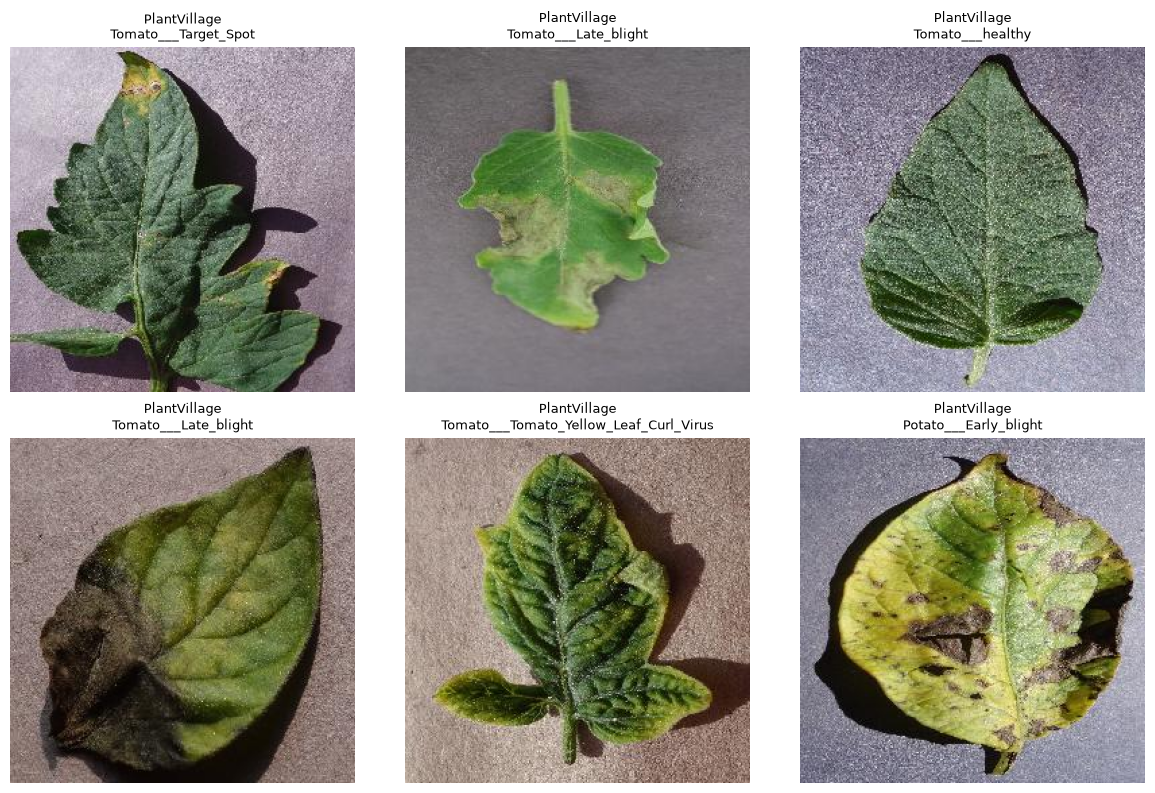

PlantVillage data\raw\plantvillage\raw\color\Tomato___Target_Spot\f7509e1d-28fb-40ce-9002-bfa0a6a53b67___Com.G_TgS_FL 8002.JPG
PlantVillage data\raw\plantvillage\raw\color\Tomato___Late_blight\989d984b-eaef-4ae1-a850-c2ae65961bdf___GHLB2 Leaf 9026.JPG
PlantVillage data\raw\plantvillage\raw\color\Tomato___healthy\17cffb66-bb7f-433c-88b4-442c1f4e8cb4___RS_HL 9708.JPG
PlantVillage data\raw\plantvillage\raw\color\Tomato___Late_blight\5f866129-ebbd-413b-aa6e-cf149be553e7___RS_Late.B 5390.JPG
PlantVillage data\raw\plantvillage\raw\color\Tomato___Tomato_Yellow_Leaf_Curl_Virus\9bfe3055-ad97-450a-826b-9c4fa0541931___YLCV_NREC 2683.JPG
PlantVillage data\raw\plantvillage\raw\color\Potato___Early_blight\66a98640-59d3-4c9b-9853-773c78ac6375___RS_Early.B 6784.JPG


In [14]:
import matplotlib.pyplot as plt
from PIL import Image

pool_muestra = [("PlantVillage", p) for p in pv_rutas_cand] + [("PlantDoc", p) for p in pd_rutas_cand]
muestra = RNG.sample(pool_muestra, 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (origen, ruta) in zip(axes.flat, muestra):
    with Image.open(ruta) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(f"{origen}\n{ruta.parent.name}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

for origen, ruta in muestra:
    print(origen, ruta.relative_to(ROOT))

## Cierre

Resumen en español, sin jerga de notebook, para la reunión con el docente:
`docs/exploracion_datasets.md`. Mapeo de clases: `docs/mapeo_clases.md`. Decisiones y
hashes: `docs/bitacora/decisiones.md`. Este notebook no dejó nada en `data/splits/` ni
calculó ninguna métrica de desempeño — ver la línea correspondiente en
`docs/bitacora/accesos_test.md`.